# Rents in San Francisco 2000-2018

**Author:** Jash Damani

[Kate Pennington](https://www.katepennington.org/data) created a panel of historic Craigslist rents by scraping posts archived by the Wayback Machine. You can read more about her work here:

[What impact does new housing have on rents, displacement, and gentrification in the surrounding neighborhood? Read our interview with economist Kate Pennington about her article, \"Does Building New Housing Cause Displacement?:The Supply and Demand Effects of Construction in San Francisco.\"](https://matrix.berkeley.edu/research-article/kate-pennington-on-gentrification-and-displacement-in-san-francisco/)

In our case, we have a clean(ish) dataset with about 200K rows that correspond to Craigslist listings for renting properties in the greater SF area. The data dictionary is as follows:

| variable    | class     | description           |
|-------------|-----------|-----------------------|
| post_id     | character | Unique ID             |
| date        | double    | date                  |
| year        | double    | year                  |
| nhood       | character | neighborhood          |
| city        | character | city                  |
| county      | character | county                |
| price       | double    | price in USD          |
| beds        | double    | n of beds             |
| baths       | double    | n of baths            |
| sqft        | double    | square feet of rental |
| room_in_apt | double    | room in apartment     |
| address     | character | address               |
| lat         | double    | latitude              |
| lon         | double    | longitude             |
| title       | character | title of listing      |
| descr       | character | description           |
| details     | character | additional details    |

The dataset was used in a recent [tidyTuesday](https://github.com/rfordatascience/tidytuesday) project.

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np                 
import yfinance as yf              
from datetime import datetime      
import matplotlib.cm as cm         
import matplotlib.ticker as mtick  
import warnings                    
from skimpy import skim            


warnings.filterwarnings('ignore')  

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (6.75, 6.75)


In [2]:
# Download rent data

rent = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2022/2022-07-05/rent.csv')

print("Data shape:", rent.shape)

print("\nData info:")

# Printing the dataset's variables, their data types etc.
print(rent.info())

Data shape: (200796, 17)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200796 entries, 0 to 200795
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200796 non-null  object 
 1   date         200796 non-null  int64  
 2   year         200796 non-null  int64  
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  int64  
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  int64  
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8016 non-null    object 
dtypes: float64(5), int64(4), objec

What are the variable types? Do they all correspond to what they really are? Which variables have most missing values?

In [3]:
# Data inspection


# Calculating the total no. of missing values in each column of the dataset

# Sorts variables with missing values in ascending order
print(rent.isna().sum().sort_values(ascending=False))

# Printing out the datatypes
print(rent.dtypes)
# Printing out a sample- the first few rows
rent.head()

descr          197542
address        196888
lon            196484
lat            193145
details        192780
baths          158121
sqft           136117
beds             6608
title            2517
county           1394
price               0
date                0
room_in_apt         0
city                0
nhood               0
year                0
post_id             0
dtype: int64
post_id         object
date             int64
year             int64
nhood           object
city            object
county          object
price            int64
beds           float64
baths          float64
sqft           float64
room_in_apt      int64
address         object
lat            float64
lon            float64
title           object
descr           object
details         object
dtype: object


,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005,alameda,alameda,alameda,1250,2.0,2.0,NaN,0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005,alameda,alameda,alameda,1295,2.0,NaN,NaN,0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004,alameda,alameda,alameda,1100,2.0,NaN,NaN,0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012,alameda,alameda,alameda,1425,1.0,NaN,735.0,0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004,alameda,alameda,alameda,890,1.0,NaN,NaN,0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


The top 20 cities in terms of % of classifieds between 2000-2018.

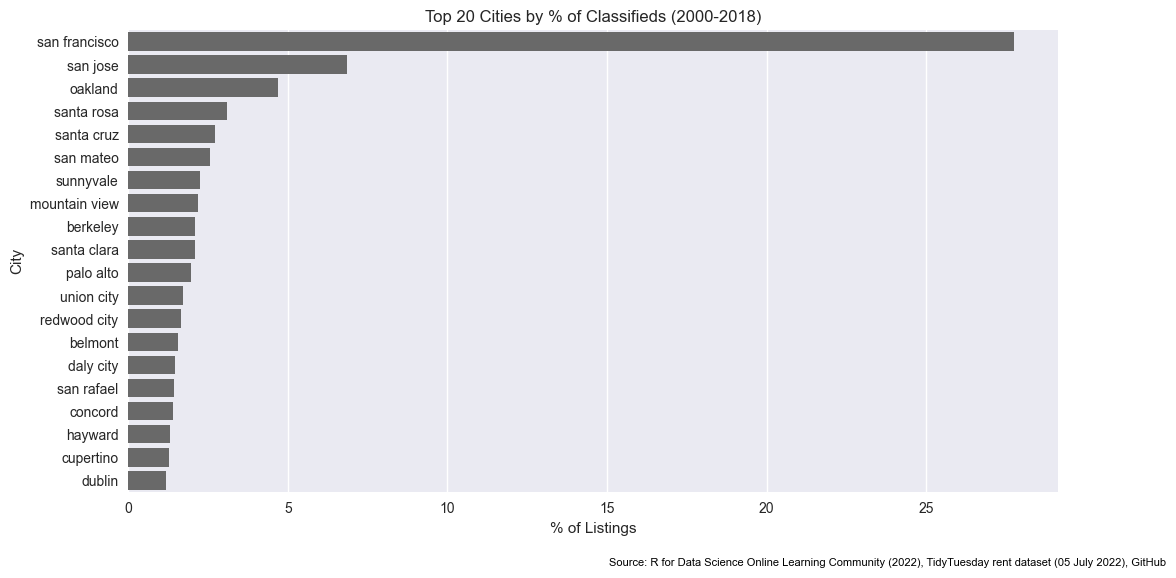

In [4]:
# Top 20 cities by percentage of listings

# Calculate number of listings per city
city_counts = rent['city'].value_counts()

# Convert counts to percentage
city_percent = (city_counts / city_counts.sum()) * 100

# Select top 20 cities
top20 = city_percent.head(20)

# Bar plot
plt.figure(figsize=(12, 6))
sns.barplot(y=top20.index, x=top20.values,color='dimgray')
plt.title("Top 20 Cities by % of Classifieds (2000-2018)")
plt.xlabel("% of Listings")
plt.ylabel("City")
plt.yticks(rotation=0, ha="right")
plt.figtext(
    0.99, 0.0,
    "Source: R for Data Science Online Learning Community (2022), "
    "TidyTuesday rent dataset (05 July 2022), GitHub",
    ha="right", va="top", fontsize=8, color="black"
)
plt.show()

The evolution of median prices in San Francisco for 0, 1, 2, and 3 bedrooms listings.

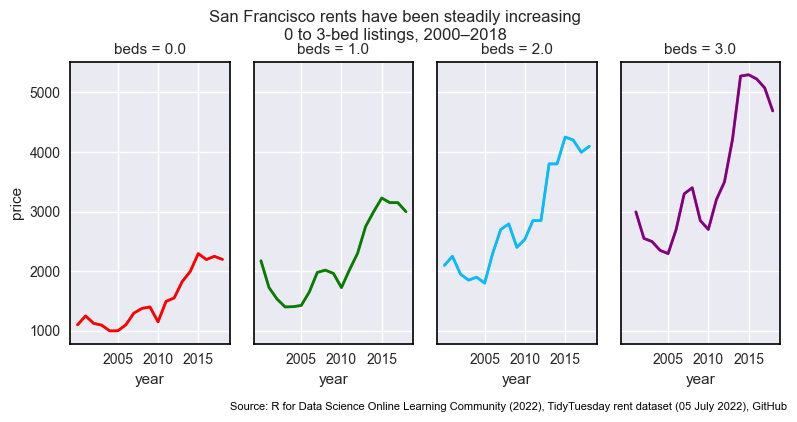

In [5]:
sf = rent[(rent['city'].str.lower().str.contains("san francisco")) &
          (rent['beds'].isin([0, 1, 2, 3]))]

# Compute median price per year per number of bedrooms
median_prices = sf.groupby(['year', 'beds'])['price'].median().reset_index()

# Color map for beds
color_map = {0: "red", 1: "green", 2: "deepskyblue", 3: "purple"}

# Plot with facet grid
g = sns.FacetGrid(median_prices, col="beds", col_wrap=4, sharey=True, height=4, aspect=0.5,
                  despine=False)  # keep spines for border
g.map_dataframe(sns.lineplot, x="year", y="price", color=None)

# Apply custom colors
for ax, bed in zip(g.axes.flat, sorted(median_prices['beds'].unique())):
    data = median_prices[median_prices['beds'] == bed]
    ax.plot(data['year'], data['price'], color=color_map[bed], linewidth=2)
    ax.set_xticks([2005, 2010, 2015])  # x-axis ticks
    for spine in ax.spines.values():
        spine.set_edgecolor("black")   # black border
        spine.set_linewidth(1.2)

# Add title
plt.subplots_adjust(top=0.85)
g.fig.suptitle("San Francisco rents have been steadily increasing\n0 to 3-bed listings, 2000–2018")

plt.figtext(
    0.99, 0.0,
    "Source: R for Data Science Online Learning Community (2022), "
    "TidyTuesday rent dataset (05 July 2022), GitHub",
    ha="right", va="top", fontsize=8, color="black"
)

plt.show()

Median rental prices for the top 12 cities in the Bay area (for 1 bedroom rentals).

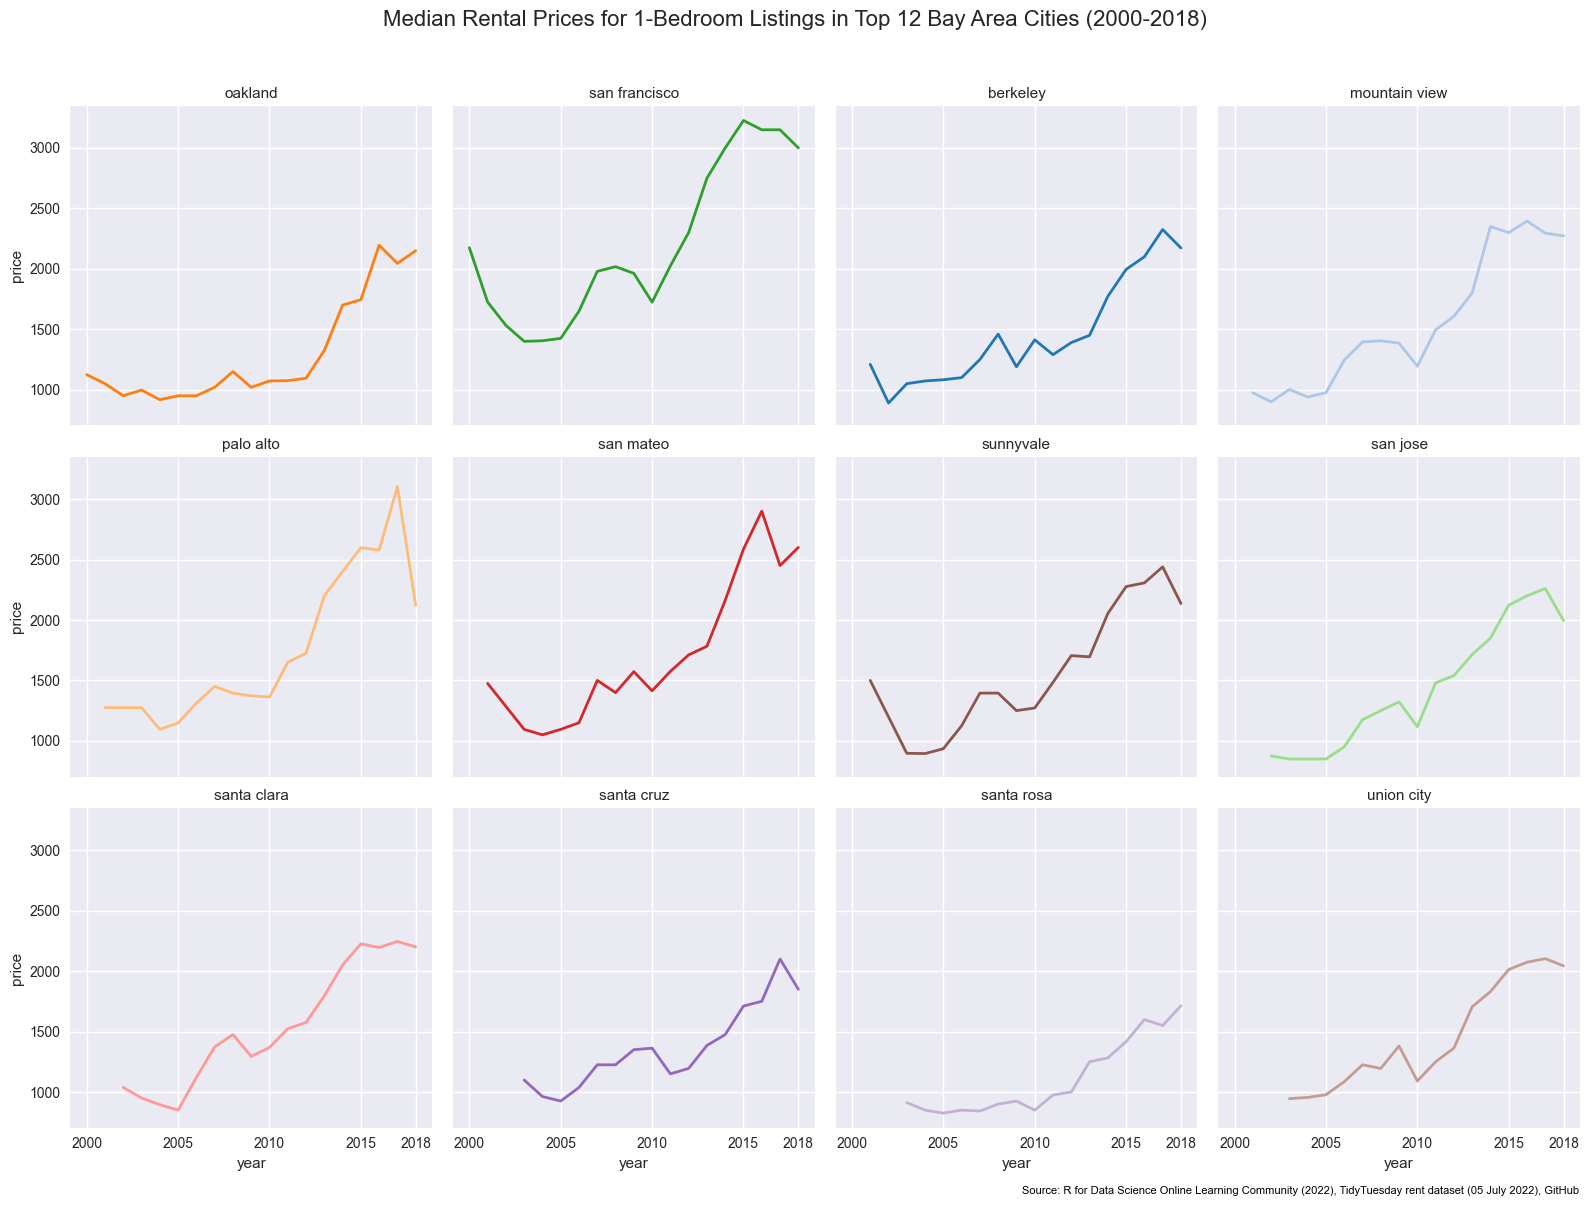

In [6]:
# Median rental prices for top 12 cities (in terms of number of ads) in Bay Area
#only 1-bedroom flat, and each graph for each city
top12_cities = rent['city'].value_counts().head(12).index.tolist()
top12_cities = sorted(top12_cities)

# Filter for Bay Area, 1-bedroom, years 2000-2018, and top 12 cities
top12 = rent[(rent['city'].isin(top12_cities)) & (rent['beds'] == 1) ]
median_prices = top12.groupby(['year', 'city'])['price'].median().reset_index()
median_prices_pivot = median_prices.pivot(index='year', columns='city', values='price')

base_palette = sns.color_palette("tab20", n_colors=len(top12_cities))
color_map = {city: base_palette[i] for i, city in enumerate(top12_cities)}

g = sns.FacetGrid(median_prices, col="city", col_wrap=4, sharey=True, height=4, aspect=1)

# plot each city's line with hue for color
g.map_dataframe(sns.lineplot, x="year", y="price", hue="city", palette=color_map, legend=False, linewidth=2)
g.set_titles("{col_name}")
# xticks and spines
for ax in g.axes.flatten():
    ax.set_xticks([2000, 2005, 2010, 2015, 2018])

# title and layout
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Median Rental Prices for 1-Bedroom Listings in Top 12 Bay Area Cities (2000-2018)", fontsize=16)

plt.figtext(
    0.99, 0.0,
    "Source: R for Data Science Online Learning Community (2022), "
    "TidyTuesday rent dataset (05 July 2022), GitHub",
    ha="right", va="top", fontsize=8, color="black"
)
plt.show()

The trend in all the graphs is similar in a manner that initially they show a decrease, after which they increase, then decrease and then increase again before finally decreasing. We can correlate this trend with a few external circumstances in those years. More specifically:

- As a historically landmark event, the housing bubble burst in 2008 in the US causing an economic meltdown which can be interpreted by the rent prices dropping during that period.
- The overall upward trend in every 1-bed listings until 2015-2016 could be an indicator of upward trend of the economy up until that period (e.g. GDP growth).
- A drop in listings is observed in almost every area during 2017-18.This shows that less people were able to afford living by themseleves during that period. This drop could hence be an indicator of a downturn on salaries or increase in unemployment.
- Different average prices through the years (e.g. San Francisco prices are on average higher than on berkeley area): This is could also be an indicator of higher salaries in San Fransisco area compared to berkeley